<a href="https://colab.research.google.com/github/valentinamoreno4321-cpu/programacion1/blob/main/Tarea5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print(" Paquetes importados correctamente")

 Paquetes importados correctamente


In [5]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('s_capitulos.csv', sep=None, engine='python')

print(f"\n Dimensiones del dataset: {df.shape}")
print(f"\n Columnas disponibles:\n{df.columns.tolist()}")
print(f"\n Primeras filas:")
df.head()

Saving s_capitulos.csv to s_capitulos.csv

📊 Dimensiones del dataset: (28858, 17)

📋 Columnas disponibles:
['S_01', 'S_02_A', 'S_02_A_01', 'S_02_B', 'S_02_B_01', 'S_02_C', 'S_02_C_01', 'S_02_D', 'S_02_D_01', 'S_02_E', 'S_02_E_01', 'S_02_F', 'S_02_F_01', 'DIRECTORIO', 'SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN']

🔍 Primeras filas:


,S_01,S_02_A,S_02_A_01,S_02_B,S_02_B_01,S_02_C,S_02_C_01,S_02_D,S_02_D_01,S_02_E,S_02_E_01,S_02_F,S_02_F_01,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN
0,1,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,1,2,1,2
1,1,1.0,1.0,1.0,1.0,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2,1,1,1
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,1,1
3,1,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,6,1,1,1
4,1,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,8,1,1,1


In [6]:
# Variables explicativas y variable objetivo
features = ['S_02_A', 'S_02_B', 'S_02_C', 'S_02_D', 'S_02_E', 'S_02_F', 'SECUENCIA_ENCUESTA']
target = 'S_01'

# Seleccionar columnas relevantes
data = df[features + [target]].copy()

# Revisar valores nulos
print(f"\n Valores nulos por columna:")
print(data.isnull().sum())

# Imputar valores nulos con la moda (valor más frecuente)
for col in data.columns:
    data[col] = data[col].fillna(data[col].mode()[0])

print(f"\n Valores nulos después de imputación:")
print(data.isnull().sum())

# Convertir variable objetivo: 1=consumidor, 0=no consumidor
data[target] = data[target].map({1: 1, 2: 0})

print(f"\n Distribución de la variable objetivo (S_01):")
print(data[target].value_counts())
print(f"\nPorcentaje consumidores: {data[target].mean()*100:.1f}%")
print(f"Porcentaje no consumidores: {(1-data[target].mean())*100:.1f}%")


 Valores nulos por columna:
S_02_A                7600
S_02_B                7600
S_02_C                7600
S_02_D                7600
S_02_E                7600
S_02_F                7600
SECUENCIA_ENCUESTA       0
S_01                     0
dtype: int64

 Valores nulos después de imputación:
S_02_A                0
S_02_B                0
S_02_C                0
S_02_D                0
S_02_E                0
S_02_F                0
SECUENCIA_ENCUESTA    0
S_01                  0
dtype: int64

 Distribución de la variable objetivo (S_01):
S_01
1    21258
0     7600
Name: count, dtype: int64

Porcentaje consumidores: 73.7%
Porcentaje no consumidores: 26.3%


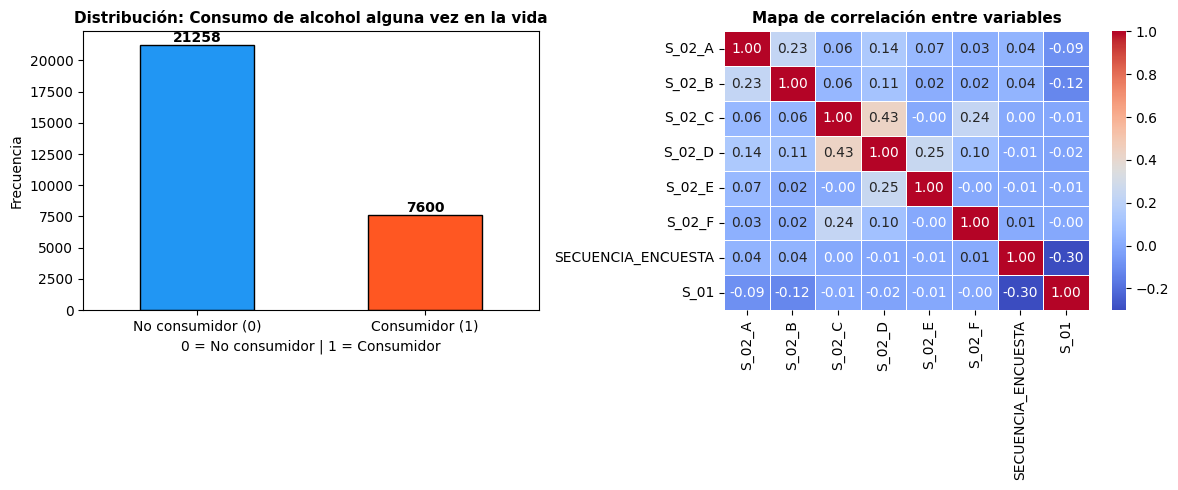

 Análisis exploratorio completado


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribución de la variable objetivo
data[target].value_counts().plot(kind='bar', ax=axes[0],
                                  color=['#2196F3', '#FF5722'],
                                  edgecolor='black')
axes[0].set_title('Distribución: Consumo de alcohol alguna vez en la vida',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('0 = No consumidor | 1 = Consumidor')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['No consumidor (0)', 'Consumidor (1)'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Correlación entre variables
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Mapa de correlación entre variables', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Análisis exploratorio completado")

In [9]:
X = data[features]
y = data[target]

# División entrenamiento / prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Tamaño conjunto entrenamiento: {X_train.shape}")
print(f" Tamaño conjunto prueba: {X_test.shape}")

# Estandarización
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


 Tamaño conjunto entrenamiento: (23086, 7)
 Tamaño conjunto prueba: (5772, 7)


In [10]:
print(f"\n Distribución antes de SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f"\n Distribución después de SMOTE:")
print(pd.Series(y_train_bal).value_counts())


 Distribución antes de SMOTE:
S_01
1    17006
0     6080
Name: count, dtype: int64

 Distribución después de SMOTE:
S_01
1    17006
0    17006
Name: count, dtype: int64


In [12]:
modelos = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión':   DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_bal, y_train_bal)
    y_pred = modelo.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = {'modelo': modelo, 'predicciones': y_pred, 'accuracy': acc}
    print(f"\n{'='*50}")
    print(f" {nombre}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print(f"\nReporte de clasificación:")
    print(classification_report(y_test, y_pred,
                                 target_names=['No consumidor', 'Consumidor']))


 Regresión Logística
Accuracy: 0.7853

Reporte de clasificación:
               precision    recall  f1-score   support

No consumidor       0.62      0.49      0.54      1520
   Consumidor       0.83      0.89      0.86      4252

     accuracy                           0.79      5772
    macro avg       0.72      0.69      0.70      5772
 weighted avg       0.77      0.79      0.78      5772


 Árbol de Decisión
Accuracy: 0.7855

Reporte de clasificación:
               precision    recall  f1-score   support

No consumidor       0.62      0.49      0.54      1520
   Consumidor       0.83      0.89      0.86      4252

     accuracy                           0.79      5772
    macro avg       0.72      0.69      0.70      5772
 weighted avg       0.77      0.79      0.78      5772


 Random Forest
Accuracy: 0.7857

Reporte de clasificación:
               precision    recall  f1-score   support

No consumidor       0.62      0.49      0.54      1520
   Consumidor       0.83      0.8

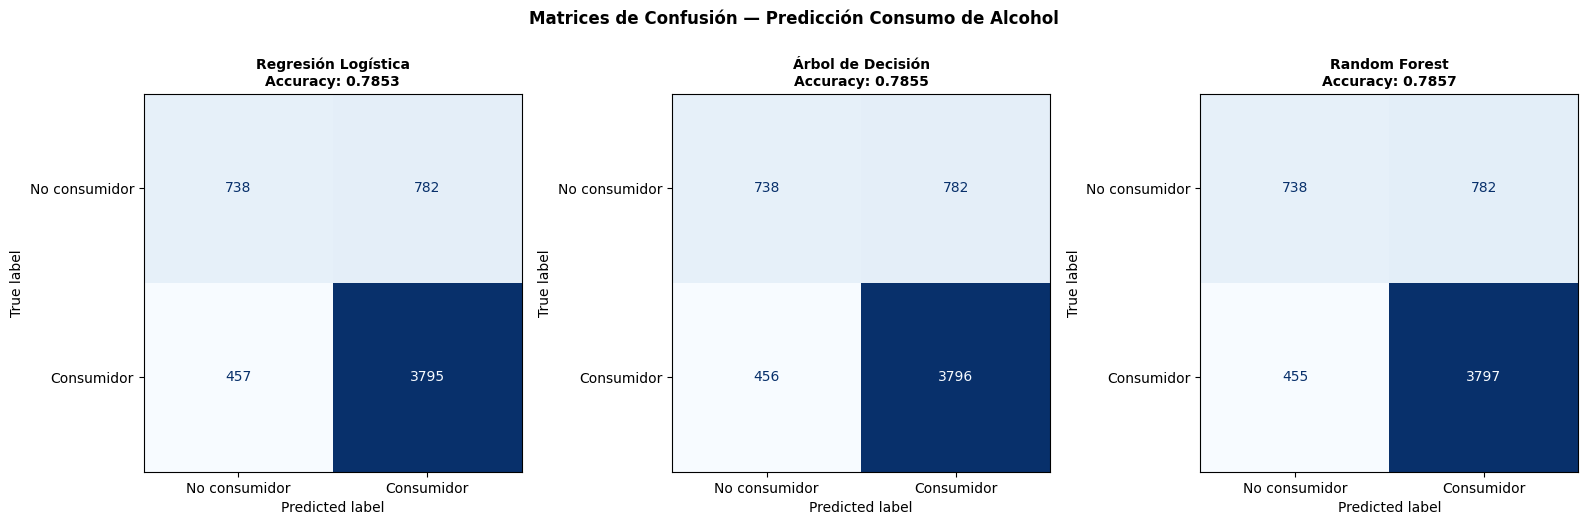

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['predicciones'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No consumidor', 'Consumidor'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{nombre}\nAccuracy: {res['accuracy']:.4f}",
                  fontsize=10, fontweight='bold')

plt.suptitle('Matrices de Confusión — Predicción Consumo de Alcohol',
              fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

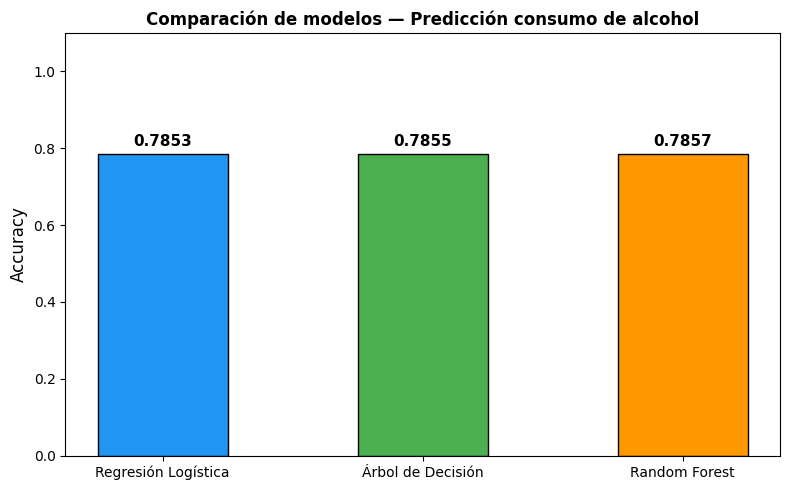

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

nombres = list(resultados.keys())
accuracies = [res['accuracy'] for res in resultados.values()]
colores = ['#2196F3', '#4CAF50', '#FF9800']

bars = ax.bar(nombres, accuracies, color=colores, edgecolor='black', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de modelos — Predicción consumo de alcohol',
              fontsize=12, fontweight='bold')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

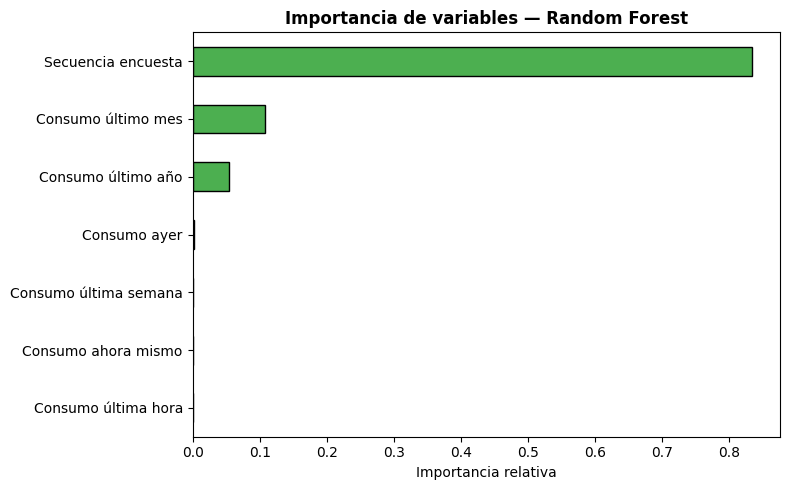

In [15]:
rf_model = resultados['Random Forest']['modelo']
importancias = pd.Series(rf_model.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='#4CAF50', edgecolor='black')
ax.set_title('Importancia de variables — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')

etiquetas = {
    'S_02_A': 'Consumo último año',
    'S_02_B': 'Consumo último mes',
    'S_02_C': 'Consumo última semana',
    'S_02_D': 'Consumo ayer',
    'S_02_E': 'Consumo última hora',
    'S_02_F': 'Consumo ahora mismo',
    'SECUENCIA_ENCUESTA': 'Secuencia encuesta'
}
ax.set_yticklabels([etiquetas.get(v, v) for v in importancias.index])

plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
